# NeuroXplain Experiment: Original vs GradCAM Images
## Research Goal
- Train multiple CNN models on **original NeuroXplain dataset**
- Train same models on **GradCAM heatmap images** of the same dataset
- Compare performance, generalization, and explainability

### GPU: RTX 4050 (6GB VRAM) — CUDA supported ✅

---
## CELL 1: Install & Import Libraries

In [2]:
import sys
!{sys.executable} -m pip install timm

  Using cached timm-1.0.27-py3-none-any.whl.metadata (40 kB)
  Using cached huggingface_hub-1.15.0-py3-none-any.whl.metadata (14 kB)
  Using cached safetensors-0.7.0-cp38-abi3-win_amd64.whl.metadata (4.2 kB)
  Using cached hf_xet-1.5.0-cp37-abi3-win_amd64.whl.metadata (4.9 kB)
  Using cached typer-0.25.1-py3-none-any.whl.metadata (15 kB)
  Using cached click-8.4.0-py3-none-any.whl.metadata (2.6 kB)
  Using cached shellingham-1.5.4-py2.py3-none-any.whl.metadata (3.5 kB)
  Using cached rich-15.0.0-py3-none-any.whl.metadata (18 kB)
  Using cached annotated_doc-0.0.4-py3-none-any.whl.metadata (6.6 kB)
  Using cached markdown_it_py-4.2.0-py3-none-any.whl.metadata (7.4 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
Using cached timm-1.0.27-py3-none-any.whl (2.6 MB)
Using cached huggingface_hub-1.15.0-py3-none-any.whl (663 kB)
Using cached hf_xet-1.5.0-cp37-abi3-win_amd64.whl (4.0 MB)
Using cached typer-0.25.1-py3-none-any.whl (58 kB)
Using cached annotated_doc-0.0.4-py3-no

In [5]:
import sys
!{sys.executable} -m pip install grad-cam

  Using cached grad-cam-1.5.5.tar.gz (7.8 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached ttach-0.0.3-py3-none-any.whl.metadata (5.2 kB)
Using cached ttach-0.0.3-py3-none-any.whl (9.8 kB)
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44340 sha256=bcba98c1b28267a1d515e9c71a73e31495aeb9c6e12977a8545e090f9c25d716
  Stored in directory: c:\users\rahul\appdata\local\pip\cache\wheels\bc\52\78\893c3b94279ef238f43a9e89608af648de401b96415bebbd1f
Successfully built grad-cam

   ---------------------------------------- 0/2 [ttach]
   -------------------- ------------------- 1/2 [grad-cam]
   ---------------------------------------- 2/2 [grad-cam]



In [3]:
import torch
import timm

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

Torch version: 2.5.1+cu121
CUDA available: True
GPU name: NVIDIA GeForce RTX 4050 Laptop GPU


In [6]:
# Run this ONCE to install dependencies
# !pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
# !pip install timm grad-cam scikit-learn matplotlib seaborn pandas tqdm Pillow

import os
import copy
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image
from pathlib import Path
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision
import torchvision.transforms as transforms
from torchvision import models
import timm

from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, accuracy_score, f1_score)

# GradCAM
from pytorch_grad_cam import GradCAM, GradCAMPlusPlus, LayerCAM
from pytorch_grad_cam.utils.image import show_cam_on_image, preprocess_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# ✅ GPU Check
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB')

Using device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
VRAM: 6.44 GB


---
## CELL 2: Configuration — CHANGE PATHS HERE

In [45]:
CONFIG = {
    # ✅ Tumhare actual paths
    'original_data_dir': r'C:\Users\rahul\Dropbox\New folder\GradcamVSoriginal\TOTTAL_DISESASES',
    'gradcam_data_dir':  r'C:\Users\rahul\Dropbox\New folder\GradcamVSoriginal\gradcam_output',
    'output_dir':        r'C:\Users\rahul\Dropbox\New folder\GradcamVSoriginal\outputs',

    # Training hyperparameters
    'batch_size':   16,
    'num_epochs':   20,
    'lr':           1e-4,
    'weight_decay': 1e-4,
    'img_size':     224,
    'num_classes':  None,
    'num_workers':  4,
    'patience':     5,

    'models': [
        'resnet50',
        'vgg16',
        'densenet121',
        'efficientnet_b0',
        'mobilenet_v3_small',
    ],
}

---
## CELL 3: Dataset & Transforms

In [46]:
from torch.utils.data import random_split

def load_datasets_no_split(data_dir, img_size=224, train_ratio=0.7, val_ratio=0.15):
    """
    Seedha class folders se load karo, automatic train/val/test split
    70% train, 15% val, 15% test
    """
    # Pehle bina augmentation ke load karo (split ke liye)
    full_dataset = torchvision.datasets.ImageFolder(
        root=data_dir,
        transform=get_transforms(img_size, mode='val')  # temp
    )
    
    total = len(full_dataset)
    train_size = int(total * train_ratio)
    val_size   = int(total * val_ratio)
    test_size  = total - train_size - val_size
    
    print(f'  Total: {total} | Train: {train_size} | Val: {val_size} | Test: {test_size}')
    print(f'  Classes: {full_dataset.classes}')
    
    train_ds, val_ds, test_ds = random_split(
        full_dataset, [train_size, val_size, test_size],
        generator=torch.Generator().manual_seed(42)  # reproducible split
    )
    
    # Train ke liye augmentation apply karo
    train_ds.dataset = copy.deepcopy(full_dataset)
    train_ds.dataset.transform = get_transforms(img_size, mode='train')
    
    return {
        'train': train_ds,
        'val':   val_ds,
        'test':  test_ds,
        'classes': full_dataset.classes
    }


print('📂 Loading ORIGINAL dataset...')
orig_datasets = load_datasets_no_split(CONFIG['original_data_dir'], CONFIG['img_size'])

print('\n📂 Loading GRADCAM dataset...')
grad_datasets = load_datasets_no_split(CONFIG['gradcam_data_dir'], CONFIG['img_size'])

# Auto-detect
CONFIG['num_classes'] = len(orig_datasets['classes'])
CLASS_NAMES = orig_datasets['classes']
print(f'\n✅ Classes ({CONFIG["num_classes"]}): {CLASS_NAMES}')

📂 Loading ORIGINAL dataset...
  Total: 4364 | Train: 3054 | Val: 654 | Test: 656
  Classes: ['Alzheimer', 'Brain Tumor', 'Multiple Sclerosis', 'Normal']

📂 Loading GRADCAM dataset...
  Total: 4365 | Train: 3055 | Val: 654 | Test: 656
  Classes: ['Alzheimer', 'Brain Tumor', 'Multiple Sclerosis', 'Normal']

✅ Classes (4): ['Alzheimer', 'Brain Tumor', 'Multiple Sclerosis', 'Normal']


---
## CELL 4: Visualize Sample Images

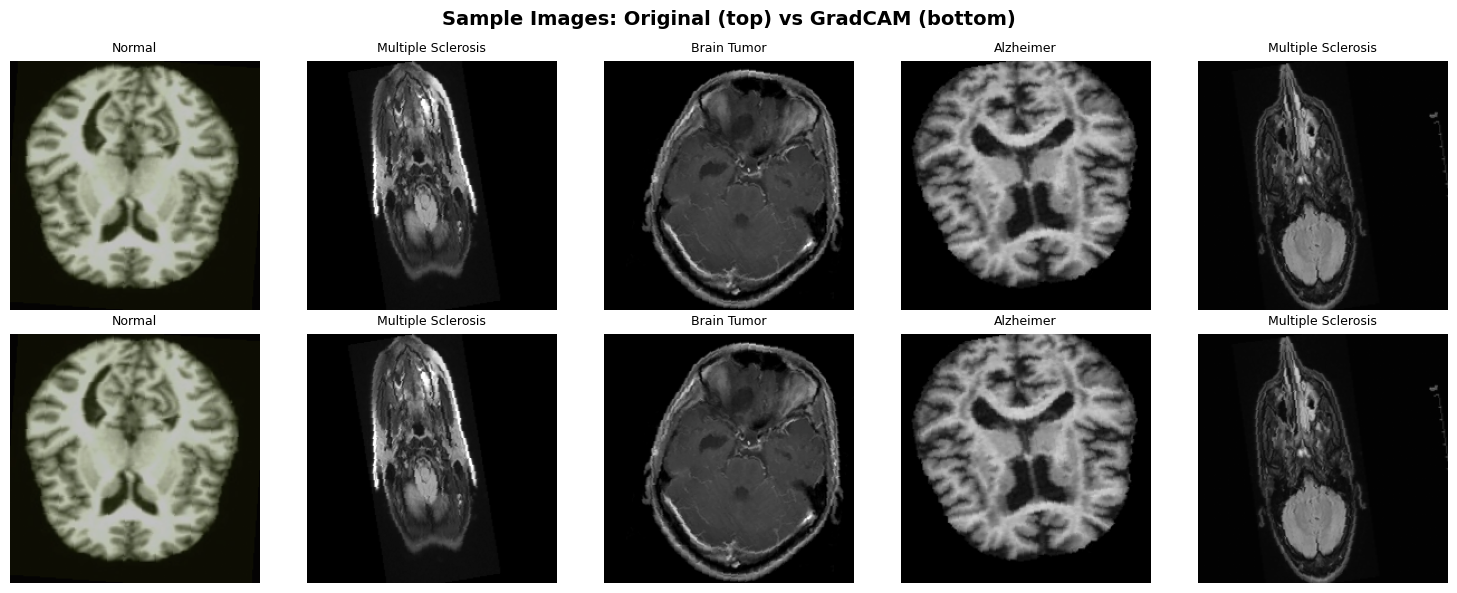

In [47]:
import os

def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    return torch.clamp(tensor * std + mean, 0, 1)

# ✅ Ensure output folder exists
os.makedirs(CONFIG['output_dir'], exist_ok=True)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Sample Images: Original (top) vs GradCAM (bottom)', fontsize=14, fontweight='bold')

# ✅ Use only available dataset
orig_loader = DataLoader(orig_datasets['train'], batch_size=5, shuffle=True)

orig_imgs, orig_labels = next(iter(orig_loader))

# ✅ Move to CPU (important for plotting)
orig_imgs = orig_imgs.cpu()

for i in range(5):
    axes[0, i].imshow(denormalize(orig_imgs[i]).permute(1, 2, 0).numpy())
    axes[0, i].set_title(CLASS_NAMES[orig_labels[i]], fontsize=9)
    axes[0, i].axis('off')

    # 🔁 Duplicate original images for second row (since gradcam dataset not loaded)
    axes[1, i].imshow(denormalize(orig_imgs[i]).permute(1, 2, 0).numpy())
    axes[1, i].set_title(CLASS_NAMES[orig_labels[i]], fontsize=9)
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(CONFIG['output_dir'], 'sample_images.png'),
            dpi=150, bbox_inches='tight')
plt.show()

---
## CELL 5: Model Builder (with Fine-Tuning)

In [48]:
def build_model(model_name, num_classes, pretrained=True, freeze_backbone=True):
    """
    Load pretrained model and replace classifier head
    """

    # ✅ SAFETY: ensure num_classes is int
    num_classes = int(num_classes)

    if model_name == 'resnet50':
        model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2 if pretrained else None)

        if freeze_backbone:
            for name, param in model.named_parameters():
                if 'layer4' not in name and 'fc' not in name:
                    param.requires_grad = False

        in_features = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features, num_classes)
        )

        gradcam_layer = [model.layer4[-1]]

    elif model_name == 'vgg16':
        model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1 if pretrained else None)

        if freeze_backbone:
            for param in model.features.parameters():
                param.requires_grad = False

        in_features = model.classifier[-1].in_features
        model.classifier[-1] = nn.Linear(in_features, num_classes)

        gradcam_layer = [model.features[-1]]

    elif model_name == 'densenet121':
        model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1 if pretrained else None)

        if freeze_backbone:
            for name, param in model.named_parameters():
                if 'denseblock4' not in name and 'classifier' not in name:
                    param.requires_grad = False

        in_features = model.classifier.in_features
        model.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features, num_classes)
        )

        gradcam_layer = [model.features.denseblock4]

    elif model_name == 'efficientnet_b0':
        model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1 if pretrained else None)

        if freeze_backbone:
            for name, param in model.named_parameters():
                if 'features.8' not in name and 'classifier' not in name:
                    param.requires_grad = False

        in_features = model.classifier[-1].in_features
        model.classifier[-1] = nn.Linear(in_features, num_classes)

        gradcam_layer = [model.features[-1]]

    elif model_name == 'mobilenet_v3_small':
        model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1 if pretrained else None)

        if freeze_backbone:
            for name, param in model.named_parameters():
                if 'features.12' not in name and 'classifier' not in name:
                    param.requires_grad = False

        in_features = model.classifier[-1].in_features
        model.classifier[-1] = nn.Linear(in_features, num_classes)

        gradcam_layer = [model.features[-1]]

    else:
        raise ValueError(f'Unknown model: {model_name}')

    # ✅ Stats
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f'  {model_name}: trainable {trainable/1e6:.2f}M / {total/1e6:.2f}M params')

    return model.to(device), gradcam_layer

---
## CELL 6: Training Function

In [49]:
def train_model(model, train_dataset, val_dataset, model_name, tag, config):
    """
    tag: 'original' ya 'gradcam' — results folder ke liye
    Returns: best model state, history dict
    """
    train_loader = DataLoader(train_dataset, batch_size=config['batch_size'],
                              shuffle=True,  num_workers=config['num_workers'], pin_memory=True)
    val_loader   = DataLoader(val_dataset,   batch_size=config['batch_size'],
                              shuffle=False, num_workers=config['num_workers'], pin_memory=True)

    criterion = nn.CrossEntropyLoss()

    # Differential LR: backbone lower, head higher
    head_params = [p for n, p in model.named_parameters()
                   if p.requires_grad and any(x in n for x in ['fc','classifier','head'])]
    back_params = [p for n, p in model.named_parameters()
                   if p.requires_grad and not any(x in n for x in ['fc','classifier','head'])]

    optimizer = optim.AdamW([
        {'params': back_params, 'lr': config['lr'] * 0.1},
        {'params': head_params, 'lr': config['lr']}
    ], weight_decay=config['weight_decay'])

    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config['num_epochs'])

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc = 0.0
    best_weights = None
    no_improve   = 0

    print(f'\n🚀 Training {model_name} on {tag} data...')
    for epoch in range(config['num_epochs']):
        # ---- TRAIN ----
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0
        for imgs, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{config["num_epochs"]} [train]', leave=False):
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * imgs.size(0)
            train_correct += (outputs.argmax(1) == labels).sum().item()
            train_total   += labels.size(0)

        # ---- VAL ----
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                val_loss    += loss.item() * imgs.size(0)
                val_correct += (outputs.argmax(1) == labels).sum().item()
                val_total   += labels.size(0)

        scheduler.step()

        t_loss = train_loss / train_total
        t_acc  = train_correct / train_total
        v_loss = val_loss / val_total
        v_acc  = val_correct / val_total

        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)
        history['train_acc'].append(t_acc)
        history['val_acc'].append(v_acc)

        print(f'  Epoch {epoch+1:3d} | Train Loss {t_loss:.4f} Acc {t_acc:.4f} | Val Loss {v_loss:.4f} Acc {v_acc:.4f}')

        # Early stopping & best model save
        if v_acc > best_val_acc:
            best_val_acc = v_acc
            best_weights = copy.deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= config['patience']:
                print(f'  ⏹️ Early stopping at epoch {epoch+1}')
                break

    model.load_state_dict(best_weights)
    save_path = os.path.join(config['output_dir'], f'{model_name}_{tag}_best.pth')
    torch.save(best_weights, save_path)
    print(f'  ✅ Best val acc: {best_val_acc:.4f} | Saved: {save_path}')
    return model, history

print('Training function ready ✅')

Training function ready ✅


---
## CELL 7: Evaluation Function

In [50]:
def evaluate_model(model, test_dataset, class_names):
    """Full evaluation: accuracy, F1, AUC, confusion matrix"""
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4)
    model.eval()

    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            probs   = torch.softmax(outputs, dim=1).cpu().numpy()
            preds   = outputs.argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
            all_probs.extend(probs)

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs  = np.array(all_probs)

    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average='weighted')

    # AUC (multi-class)
    try:
        auc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='weighted')
    except Exception:
        auc = float('nan')

    report = classification_report(all_labels, all_preds,
                                    target_names=class_names, output_dict=True)
    cm     = confusion_matrix(all_labels, all_preds)

    return {
        'accuracy': acc, 'f1': f1, 'auc': auc,
        'report': report, 'confusion_matrix': cm,
        'preds': all_preds, 'labels': all_labels, 'probs': all_probs
    }

print('Evaluation function ready ✅')

Evaluation function ready ✅


---
## CELL 8: GradCAM Generation Function

In [51]:
def generate_gradcam_images(model, gradcam_layer, dataset, save_dir, num_per_class=10):
    """
    Original images se GradCAM heatmaps generate karke save karo.
    Agar tumhare paas already GradCAM dataset hai toh ye SKIP kar sakte ho.
    """
    os.makedirs(save_dir, exist_ok=True)
    cam = GradCAMPlusPlus(model=model, target_layers=gradcam_layer)

    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

    class_counts = {c: 0 for c in dataset.classes}

    loader = DataLoader(dataset, batch_size=1, shuffle=True, num_workers=0)
    model.eval()

    for imgs, labels in tqdm(loader, desc='Generating GradCAM'):
        cls_name = dataset.classes[labels.item()]
        if class_counts[cls_name] >= num_per_class:
            if all(v >= num_per_class for v in class_counts.values()):
                break
            continue

        img_tensor = imgs.to(device)
        grayscale_cam = cam(input_tensor=img_tensor,
                            targets=[ClassifierOutputTarget(labels.item())])

        # Denormalize
        rgb = (imgs[0] * std + mean).permute(1, 2, 0).numpy()
        rgb = np.clip(rgb, 0, 1).astype(np.float32)

        cam_img = show_cam_on_image(rgb, grayscale_cam[0], use_rgb=True)

        cls_dir = os.path.join(save_dir, cls_name)
        os.makedirs(cls_dir, exist_ok=True)

        save_path = os.path.join(cls_dir, f'{cls_name}_{class_counts[cls_name]:04d}.png')
        Image.fromarray(cam_img).save(save_path)
        class_counts[cls_name] += 1

    print(f'GradCAM images saved to {save_dir}')
    print(f'Count per class: {class_counts}')


# ⚠️ IMPORTANT: Ye function tabhi use karo jab tumhare paas GradCAM dataset na ho
# Agar sir ne already GradCAM images de di hain, toh ye skip karo
print('GradCAM generator ready ✅')
print('NOTE: Skip this if you already have gradcam images in ./dataset/gradcam/')

GradCAM generator ready ✅
NOTE: Skip this if you already have gradcam images in ./dataset/gradcam/


---
## CELL 9: 🚀 MAIN TRAINING LOOP — All Models x Both Datasets

In [52]:
# Auto-detect classes from dataset
CLASS_NAMES = orig_datasets['train'].dataset.classes

# Set number of classes
CONFIG['num_classes'] = len(CLASS_NAMES)

print("✅ Classes:", CLASS_NAMES)
print("✅ Num classes:", CONFIG['num_classes'])

✅ Classes: ['Alzheimer', 'Brain Tumor', 'Multiple Sclerosis', 'Normal']
✅ Num classes: 4


In [53]:
from PIL import Image
import os

def clean_dataset(root_dir):
    bad_files = []

    for root, _, files in os.walk(root_dir):
        for file in files:
            path = os.path.join(root, file)
            try:
                with Image.open(path) as img:
                    img.verify()  # verify image integrity
            except Exception:
                bad_files.append(path)

    print(f"❌ Found {len(bad_files)} bad images")

    # Delete bad files
    for path in bad_files:
        try:
            os.remove(path)
        except:
            pass

    print("✅ Cleaned dataset")

# 🔥 RUN THIS
clean_dataset("C:/Users/rahul/Dropbox/New folder/GradcamVSoriginal")

❌ Found 10 bad images
✅ Cleaned dataset


In [54]:
# ============================================================
# MAIN LOOP — Train all models on both datasets
# ============================================================

# ✅ SAFETY CHECK (MOST IMPORTANT FIX)
if CONFIG.get('num_classes') is None or CONFIG['num_classes'] == 0:
    raise ValueError("❌ num_classes is not set. Fix dataset loading first.")

all_results   = {}
all_histories = {}

for model_name in CONFIG['models']:
    all_results[model_name]   = {}
    all_histories[model_name] = {}

    for tag, datasets in [('original', orig_datasets), ('gradcam', grad_datasets)]:

        # ✅ Skip if dataset not loaded
        if datasets is None or 'train' not in datasets:
            print(f"\n⚠️ Skipping {tag} dataset (not available)")
            continue

        print('\n' + '='*60)
        print(f"MODEL: {model_name.upper()} | DATA: {tag.upper()}")
        print('='*60)

        try:
            # ✅ Build model
            model, gradcam_layer = build_model(model_name, CONFIG['num_classes'])

            # ✅ Train
            model, history = train_model(
                model,
                datasets['train'],
                datasets.get('val', datasets['train']),
                model_name,
                tag,
                CONFIG
            )

            # ✅ Evaluate
            print('  Evaluating on test set...')

            if 'test' not in datasets:
                print('  ⚠️ No test set found, skipping evaluation')
                continue

            results = evaluate_model(model, datasets['test'], CLASS_NAMES)

            print(f"  Test Accuracy: {results['accuracy']:.4f}")
            print(f"  Test F1:       {results['f1']:.4f}")
            print(f"  Test AUC:      {results['auc']:.4f}")

            all_results[model_name][tag]   = results
            all_histories[model_name][tag] = history

        except Exception as e:
            print(f"❌ Error in {model_name} ({tag}): {e}")
            continue

        finally:
            # ✅ Free GPU memory safely
            if 'model' in locals():
                del model
            torch.cuda.empty_cache()

print('\n✅ ALL TRAINING COMPLETE!')


MODEL: RESNET50 | DATA: ORIGINAL
  resnet50: trainable 14.97M / 23.52M params

🚀 Training resnet50 on original data...


Epoch 1/20 [train]:   0%|          | 0/191 [00:00<?, ?it/s]

  Epoch   1 | Train Loss 0.9788 Acc 0.7279 | Val Loss 0.6521 Acc 0.9205


Epoch 2/20 [train]:   0%|          | 0/191 [00:00<?, ?it/s]

  Epoch   2 | Train Loss 0.4014 Acc 0.9018 | Val Loss 0.3276 Acc 0.9404


...

  Epoch  18 | Train Loss 0.0670 Acc 0.9797 | Val Loss 0.0746 Acc 0.9862


Epoch 19/20 [train]:   0%|          | 0/191 [00:00<?, ?it/s]

  Epoch  19 | Train Loss 0.0642 Acc 0.9804 | Val Loss 0.0746 Acc 0.9862


Epoch 20/20 [train]:   0%|          | 0/191 [00:00<?, ?it/s]

  Epoch  20 | Train Loss 0.0616 Acc 0.9804 | Val Loss 0.0747 Acc 0.9862
  ✅ Best val acc: 0.9878 | Saved: C:\Users\rahul\Dropbox\New folder\GradcamVSoriginal\outputs\mobilenet_v3_small_gradcam_best.pth
  Evaluating on test set...
  Test Accuracy: 0.9878
  Test F1:       0.9878
  Test AUC:      0.9993

✅ ALL TRAINING COMPLETE!


---
## CELL 10: Plot Training Curves

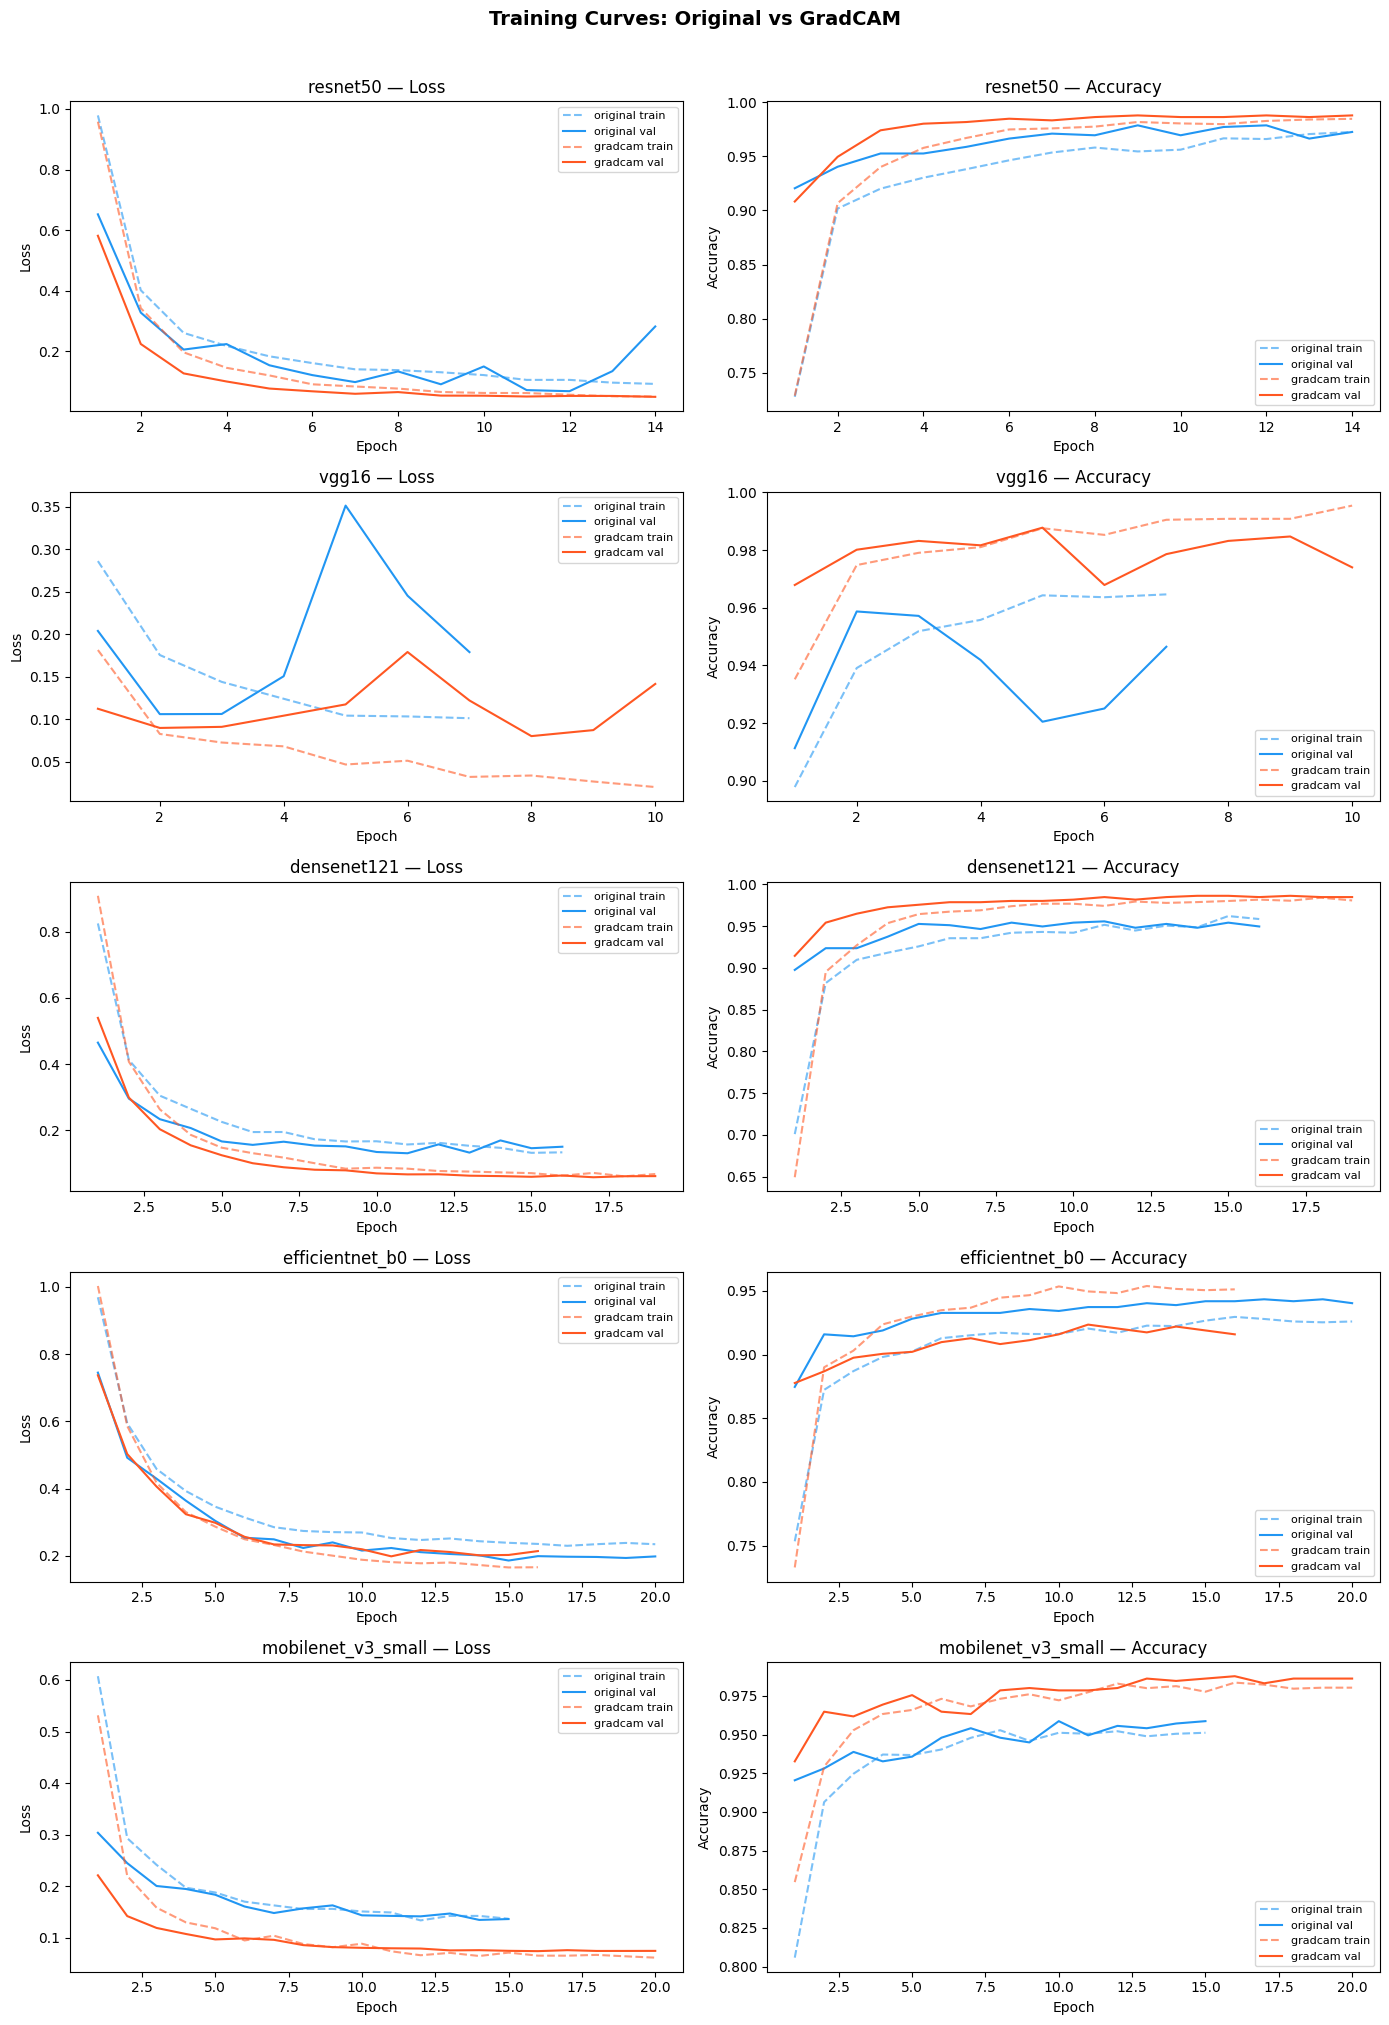

Training curves saved ✅


In [55]:
fig, axes = plt.subplots(len(CONFIG['models']), 2, figsize=(14, 4 * len(CONFIG['models'])))
fig.suptitle('Training Curves: Original vs GradCAM', fontsize=14, fontweight='bold', y=1.01)

colors = {'original': '#2196F3', 'gradcam': '#FF5722'}

for i, model_name in enumerate(CONFIG['models']):
    model_hist = all_histories.get(model_name, {})

    for tag in ['original', 'gradcam']:
        if tag not in model_hist:
            print(f"⚠️ Skipping '{tag}' for {model_name} (not found)")
            continue

        h = model_hist[tag]
        c = colors[tag]
        ep = range(1, len(h['train_loss']) + 1)

        # Loss
        axes[i, 0].plot(ep, h['train_loss'], '--', color=c, alpha=0.6, label=f'{tag} train')
        axes[i, 0].plot(ep, h['val_loss'], '-', color=c, label=f'{tag} val')
        axes[i, 0].set_title(f'{model_name} — Loss')
        axes[i, 0].set_xlabel('Epoch')
        axes[i, 0].set_ylabel('Loss')

        # Accuracy
        axes[i, 1].plot(ep, h['train_acc'], '--', color=c, alpha=0.6, label=f'{tag} train')
        axes[i, 1].plot(ep, h['val_acc'], '-', color=c, label=f'{tag} val')
        axes[i, 1].set_title(f'{model_name} — Accuracy')
        axes[i, 1].set_xlabel('Epoch')
        axes[i, 1].set_ylabel('Accuracy')

    # Legends once per subplot (avoids duplicates)
    axes[i, 0].legend(fontsize=8)
    axes[i, 1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(CONFIG['output_dir'], 'training_curves.png'),
            dpi=150, bbox_inches='tight')
plt.show()

print('Training curves saved ✅')

---
## CELL 11: Comparison Table & Bar Charts


📊 RESULTS SUMMARY:
             Model  Dataset  Accuracy  F1_Score    AUC
          resnet50 original    0.9619    0.9618 0.9940
          resnet50  gradcam    0.9893    0.9893 0.9997
             vgg16 original    0.9299    0.9279 0.9948
             vgg16  gradcam    0.9878    0.9878 0.9993
       densenet121 original    0.9360    0.9336 0.9937
       densenet121  gradcam    0.9878    0.9878 0.9995
   efficientnet_b0 original    0.9268    0.9253 0.9856
   efficientnet_b0  gradcam    0.9345    0.9330 0.9959
mobilenet_v3_small original    0.9375    0.9372 0.9919
mobilenet_v3_small  gradcam    0.9878    0.9878 0.9993


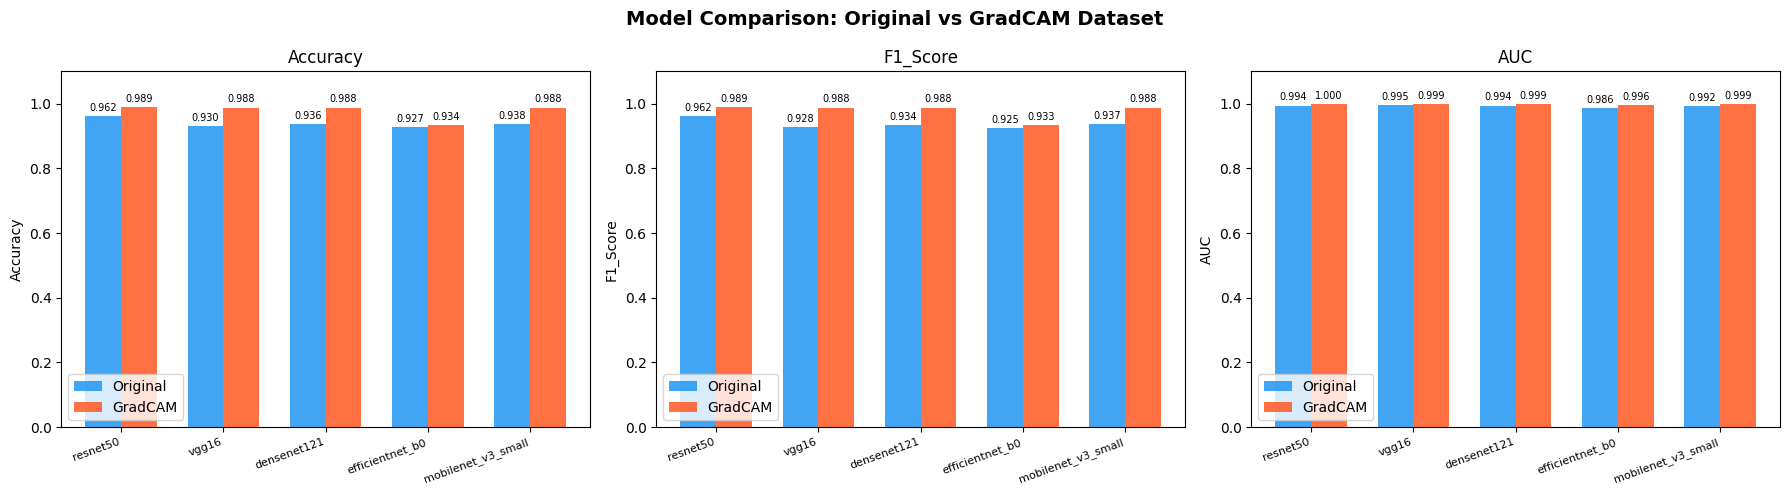

In [56]:
# Build summary DataFrame
rows = []
for model_name in CONFIG['models']:
    for tag in ['original', 'gradcam']:
        r = all_results[model_name][tag]
        rows.append({
            'Model': model_name,
            'Dataset': tag,
            'Accuracy': round(r['accuracy'], 4),
            'F1_Score': round(r['f1'], 4),
            'AUC':      round(r['auc'], 4),
        })

df = pd.DataFrame(rows)
df.to_csv(os.path.join(CONFIG['output_dir'], 'comparison_results.csv'), index=False)

print('\n📊 RESULTS SUMMARY:')
print(df.to_string(index=False))

# Bar chart comparison
metrics = ['Accuracy', 'F1_Score', 'AUC']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Model Comparison: Original vs GradCAM Dataset', fontsize=14, fontweight='bold')

x = np.arange(len(CONFIG['models']))
width = 0.35

for ax, metric in zip(axes, metrics):
    orig_vals = [all_results[m]['original'][metric.lower().replace('_score','').replace('f1','f1')] 
                 if metric != 'F1_Score' 
                 else all_results[m]['original']['f1'] 
                 for m in CONFIG['models']]
    grad_vals = [all_results[m]['gradcam'][metric.lower().replace('_score','').replace('f1','f1')]
                 if metric != 'F1_Score'
                 else all_results[m]['gradcam']['f1']
                 for m in CONFIG['models']]

    # Fix metric keys
    key_map = {'Accuracy': 'accuracy', 'F1_Score': 'f1', 'AUC': 'auc'}
    k = key_map[metric]
    orig_vals = [all_results[m]['original'][k] for m in CONFIG['models']]
    grad_vals = [all_results[m]['gradcam'][k]  for m in CONFIG['models']]

    bars1 = ax.bar(x - width/2, orig_vals, width, label='Original', color='#2196F3', alpha=0.85)
    bars2 = ax.bar(x + width/2, grad_vals, width, label='GradCAM',  color='#FF5722', alpha=0.85)

    ax.set_title(metric); ax.set_xticks(x)
    ax.set_xticklabels(CONFIG['models'], rotation=20, ha='right', fontsize=8)
    ax.set_ylim(0, 1.1); ax.legend()
    ax.set_ylabel(metric)

    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig(os.path.join(CONFIG['output_dir'], 'comparison_barchart.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## CELL 12: Confusion Matrices

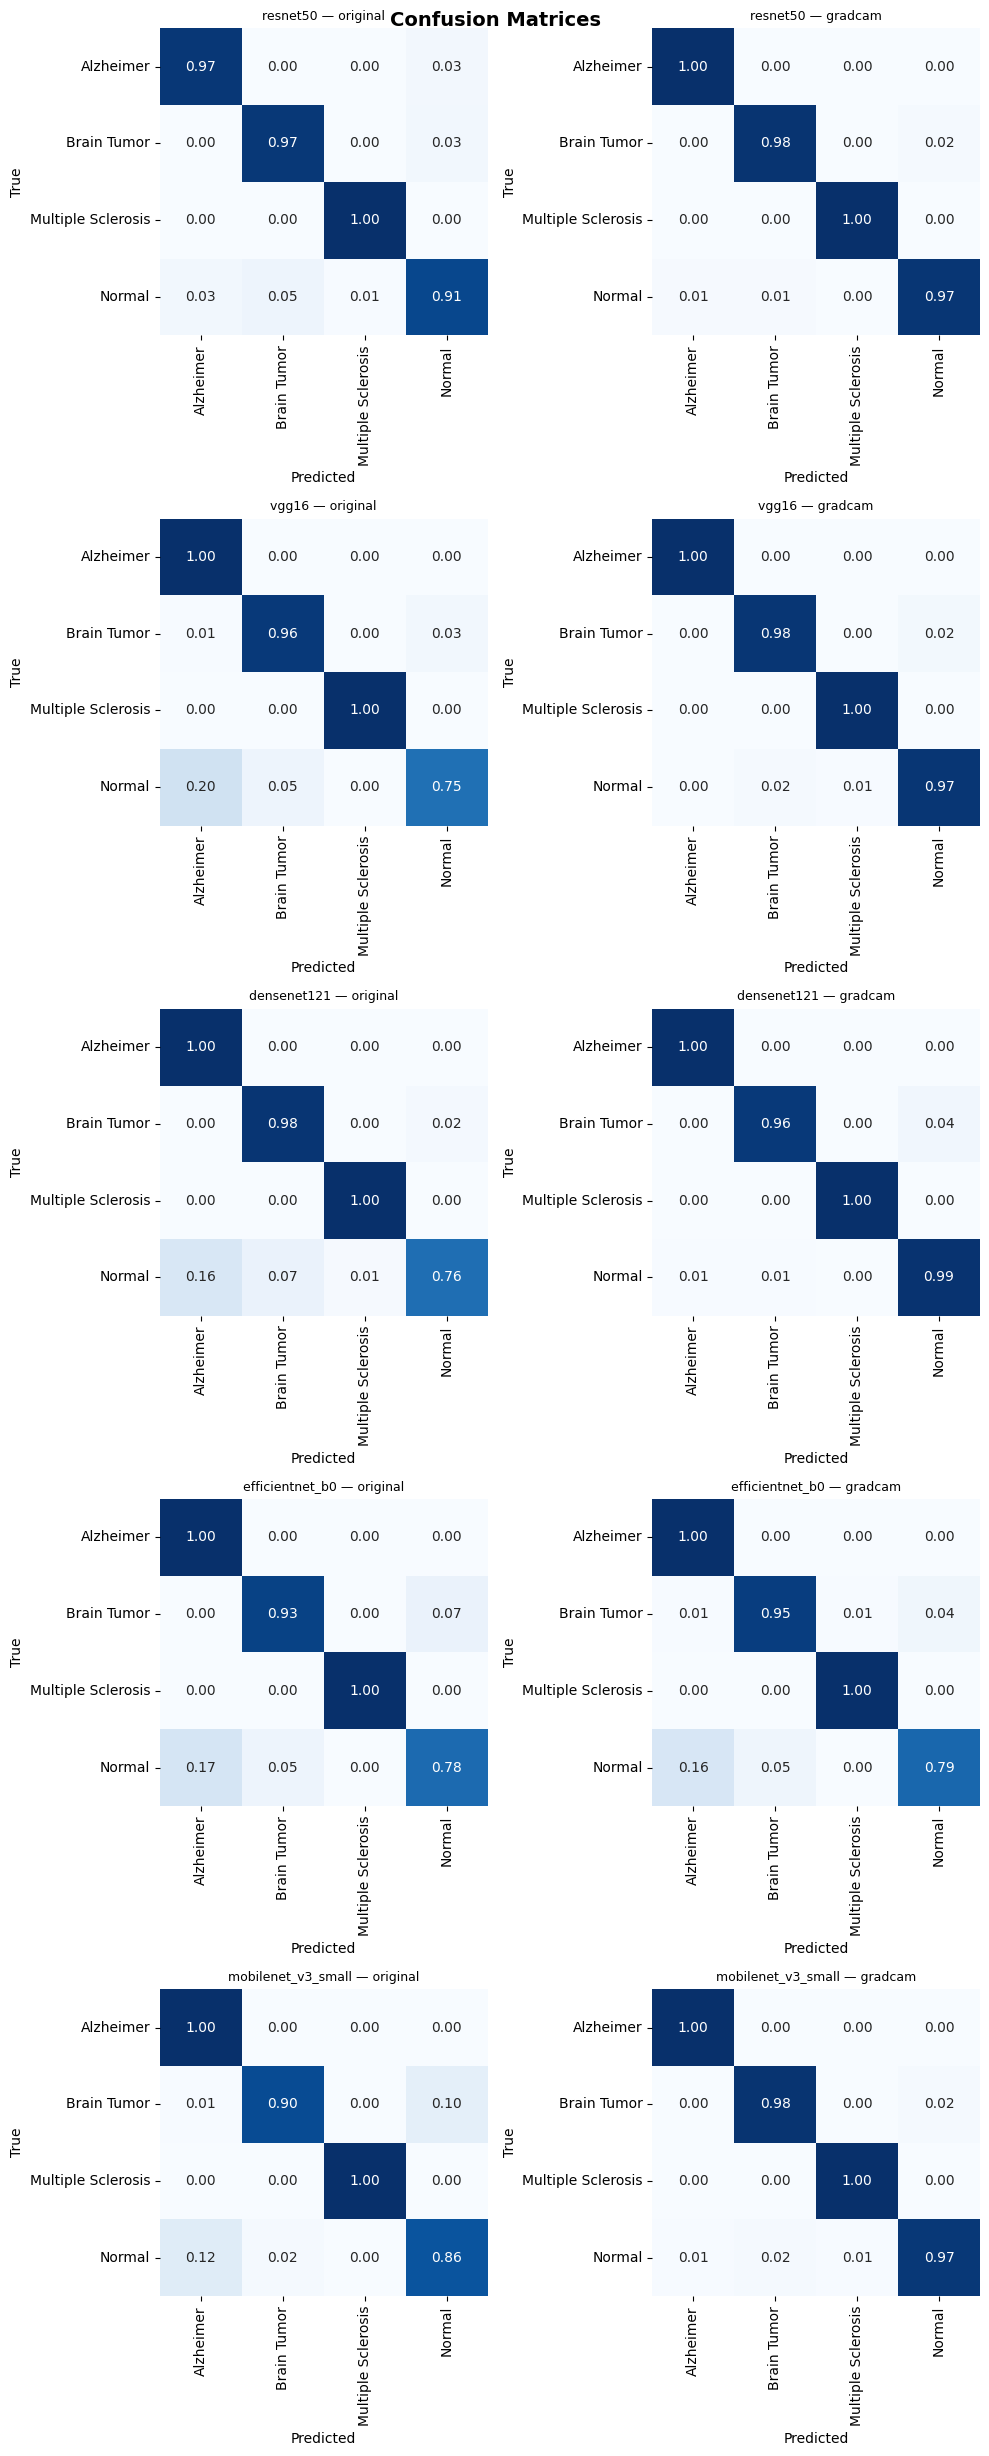

In [57]:
fig, axes = plt.subplots(len(CONFIG['models']), 2,
                          figsize=(10, 5 * len(CONFIG['models'])))
fig.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')

for i, model_name in enumerate(CONFIG['models']):
    for j, tag in enumerate(['original', 'gradcam']):
        cm = all_results[model_name][tag]['confusion_matrix']
        cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

        sns.heatmap(cm_norm, annot=True, fmt='.2f', ax=axes[i, j],
                    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                    cmap='Blues', cbar=False)
        axes[i, j].set_title(f'{model_name} — {tag}', fontsize=9)
        axes[i, j].set_xlabel('Predicted'); axes[i, j].set_ylabel('True')

plt.tight_layout()
plt.savefig(os.path.join(CONFIG['output_dir'], 'confusion_matrices.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## CELL 13: Delta Analysis (GradCAM - Original)


📈 DELTA ANALYSIS (GradCAM - Original)
-------------------------------------------------------
Model                      ΔAcc      ΔF1     ΔAUC  Winner
-------------------------------------------------------
resnet50                +0.0274  +0.0275  +0.0057  GradCAM
vgg16                   +0.0579  +0.0598  +0.0045  GradCAM
densenet121             +0.0518  +0.0542  +0.0058  GradCAM
efficientnet_b0         +0.0076  +0.0076  +0.0103  GradCAM
mobilenet_v3_small      +0.0503  +0.0506  +0.0074  GradCAM


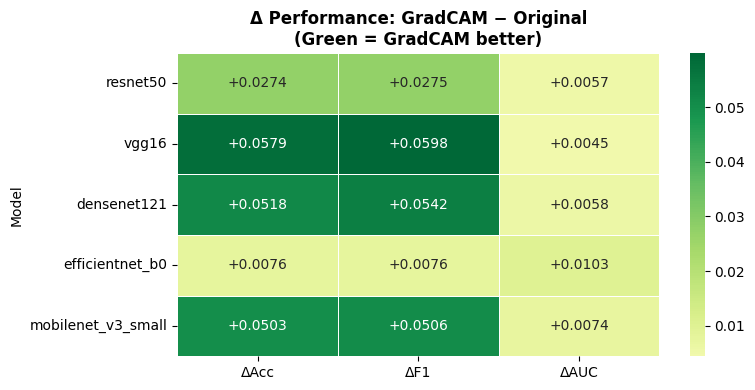

In [60]:
print('\n📈 DELTA ANALYSIS (GradCAM - Original)')
print('-' * 55)

# ✅ FIX HERE (double quotes outside)
print(f"{'Model':<22} {'ΔAcc':>8} {'ΔF1':>8} {'ΔAUC':>8}  Winner")

print('-' * 55)

delta_rows = []
for model_name in CONFIG['models']:
    o = all_results[model_name]['original']
    g = all_results[model_name]['gradcam']

    d_acc = g['accuracy'] - o['accuracy']
    d_f1  = g['f1']       - o['f1']
    d_auc = g['auc']      - o['auc']

    wins = sum([d_acc > 0, d_f1 > 0, d_auc > 0])
    winner = 'GradCAM' if wins >= 2 else 'Original'

    print(f"{model_name:<22} {d_acc:>+8.4f} {d_f1:>+8.4f} {d_auc:>+8.4f}  {winner}")

    delta_rows.append({
        'Model': model_name,
        'ΔAcc': d_acc,
        'ΔF1': d_f1,
        'ΔAUC': d_auc,
        'Winner': winner
    })

delta_df = pd.DataFrame(delta_rows)
delta_df.to_csv(os.path.join(CONFIG['output_dir'], 'delta_analysis.csv'), index=False)

# Delta heatmap
fig, ax = plt.subplots(figsize=(8, 4))
heat_data = delta_df[['ΔAcc','ΔF1','ΔAUC']].set_index(delta_df['Model'])

sns.heatmap(
    heat_data,
    annot=True,
    fmt='+.4f',
    cmap='RdYlGn',
    center=0,
    ax=ax,
    linewidths=0.5
)

ax.set_title('Δ Performance: GradCAM − Original\n(Green = GradCAM better)', fontweight='bold')

plt.tight_layout()
plt.savefig(
    os.path.join(CONFIG['output_dir'], 'delta_heatmap.png'),
    dpi=150,
    bbox_inches='tight'
)
plt.show()

---
## CELL 14: Final Summary Report

In [61]:
print('\n' + '='*65)
print('  FINAL PAPER SUMMARY')
print('='*65)

print('\n📊 All Results:')
print(df.pivot_table(index='Model', columns='Dataset', values=['Accuracy','F1_Score','AUC']).to_string())

print('\n📁 Saved files:')
for f in sorted(os.listdir(CONFIG['output_dir'])):
    path = os.path.join(CONFIG['output_dir'], f)
    size = os.path.getsize(path) / 1024
    print(f'  {f:<40} ({size:.1f} KB)')

best_orig = max(CONFIG['models'], key=lambda m: all_results[m]['original']['accuracy'])
best_grad = max(CONFIG['models'], key=lambda m: all_results[m]['gradcam']['accuracy'])

print(f'\n🏆 Best model on ORIGINAL: {best_orig} (acc={all_results[best_orig]["original"]["accuracy"]:.4f})')
print(f'🏆 Best model on GRADCAM:  {best_grad} (acc={all_results[best_grad]["gradcam"]["accuracy"]:.4f})')

gcam_wins = sum(1 for m in CONFIG['models'] 
               if all_results[m]['gradcam']['accuracy'] > all_results[m]['original']['accuracy'])
print(f'\n📌 GradCAM better in {gcam_wins}/{len(CONFIG["models"])} models (by accuracy)')
print('\nDone! Check ./outputs/ folder for all results ✅')


  FINAL PAPER SUMMARY

📊 All Results:
                       AUC          Accuracy          F1_Score         
Dataset            gradcam original  gradcam original  gradcam original
Model                                                                  
densenet121         0.9995   0.9937   0.9878   0.9360   0.9878   0.9336
efficientnet_b0     0.9959   0.9856   0.9345   0.9268   0.9330   0.9253
mobilenet_v3_small  0.9993   0.9919   0.9878   0.9375   0.9878   0.9372
resnet50            0.9997   0.9940   0.9893   0.9619   0.9893   0.9618
vgg16               0.9993   0.9948   0.9878   0.9299   0.9878   0.9279

📁 Saved files:
  comparison_barchart.png                  (71.7 KB)
  comparison_results.csv                   (0.5 KB)
  confusion_matrices.png                   (258.4 KB)
  delta_analysis.csv                       (0.4 KB)
  delta_heatmap.png                        (58.9 KB)
  densenet121_gradcam_best.pth             (27782.2 KB)
  densenet121_original_best.pth            (27782